In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn import metrics
import pickle

In [2]:
data=pd.read_csv('time separated.csv')
data.head(20)

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Shape,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
0,0,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,18
1,1,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
2,2,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
3,3,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,12
4,4,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
5,5,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,16
6,6,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,17
7,7,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,10
8,8,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,11
9,9,p10,0.1,0.9,0.0,0.0,0.02,0.0,0.08,kare,10.0,100.0,6.0,36.0,0.36,8000,kaynaksız,1,13


In [3]:
data=data.sample(frac=1)
#data= data[data['Detector_Size'] == 10]
#data.drop(['Unnamed: 0','Shape','Detector_Size','Cover_Size','CH4','CO2'],axis=1,inplace=True)
#data= data.set_index('Event')


#data= data[data['Gas_Type'] != 'p10']
data.drop(['Shape'],axis=1,inplace=True)


data= data[data['Time_Window'] == 15]
#data.drop(['Time_Window'],axis=1,inplace=True)



data= data[(data['Voltage'] >= 4500) & (data['Voltage'] <= 5500)]
#data= data[data['Detector_Size'] == 10]

#data.drop(['Voltage'],axis=1,inplace=True)


In [4]:
#groupByData = data.groupby(['Gas_Type', 'Detector_Size','Cover_Size','Voltage','Time_Window','Source'])

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 32551 to 11071
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        612 non-null    int64  
 1   Gas_Type          612 non-null    object 
 2   CH4               612 non-null    float64
 3   Ar                612 non-null    float64
 4   N2                612 non-null    float64
 5   CO2               612 non-null    float64
 6   C                 612 non-null    float64
 7   O                 612 non-null    float64
 8   H                 612 non-null    float64
 9   Detector_Size     612 non-null    float64
 10  Detector_Area     612 non-null    float64
 11  Cover_Size        612 non-null    float64
 12  Cover_Area        612 non-null    float64
 13  Cover_Area_Ratio  612 non-null    float64
 14  Voltage           612 non-null    int64  
 15  Source            612 non-null    object 
 16  Time_Window       612 non-null    int64  
 

In [6]:
data.isnull()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
32551,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49310,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
49074,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
19806,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
37271,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41759,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
48596,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
11074,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1642,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [7]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

<Axes: >

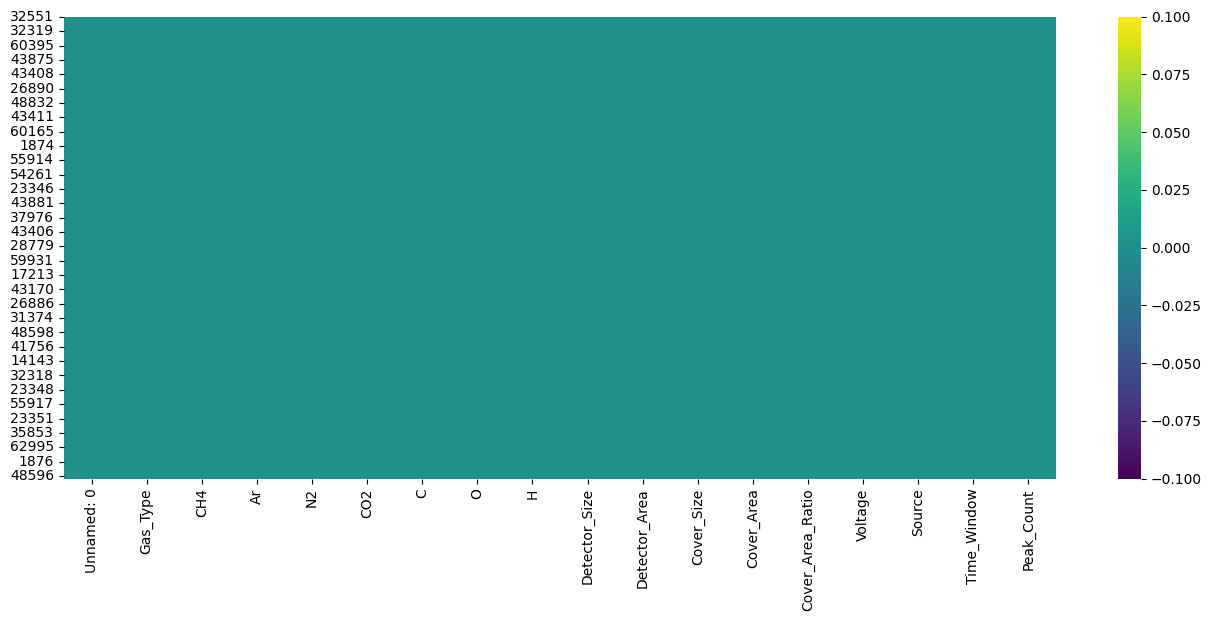

In [8]:
plt.figure(figsize=(16, 6))
sns.heatmap(data.isnull(),cmap='viridis')

In [9]:
data.dropna(inplace=True)

In [10]:
data.isnull().sum()

Unnamed: 0          0
Gas_Type            0
CH4                 0
Ar                  0
N2                  0
CO2                 0
C                   0
O                   0
H                   0
Detector_Size       0
Detector_Area       0
Cover_Size          0
Cover_Area          0
Cover_Area_Ratio    0
Voltage             0
Source              0
Time_Window         0
Peak_Count          0
dtype: int64

In [11]:
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count
32551,32551,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,4500,kaynaksız,15,7
49310,49310,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5000,kaynaksız,15,0
49074,49074,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5500,cs,15,0
19806,19806,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,5000,kaynaksız,15,45
37271,37271,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5000,cs,15,208


In [12]:
type2=pd.get_dummies(data['Gas_Type'],dtype=float)
type2

,arnco2,p10,p20
32551,0.0,0.0,1.0
49310,1.0,0.0,0.0
49074,1.0,0.0,0.0
19806,0.0,1.0,0.0
37271,0.0,0.0,1.0
...,...,...,...
41759,0.0,0.0,1.0
48596,1.0,0.0,0.0
11074,0.0,1.0,0.0
1642,0.0,1.0,0.0


In [13]:
type=pd.get_dummies(data['Source'],dtype=float)
type

,cs,kaynaksız
32551,0.0,1.0
49310,0.0,1.0
49074,1.0,0.0
19806,0.0,1.0
37271,1.0,0.0
...,...,...
41759,1.0,0.0
48596,1.0,0.0
11074,0.0,1.0
1642,1.0,0.0


In [14]:
data['KV2'] = (data['Voltage']/1000)**2
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Source,Time_Window,Peak_Count,KV2
32551,32551,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,4.00,16.00,0.16,4500,kaynaksız,15,7,20.25
49310,49310,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5000,kaynaksız,15,0,25.00
49074,49074,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,100.00,6.00,36.00,0.36,5500,cs,15,0,30.25
19806,19806,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,45.97,6.68,44.62,0.97,5000,kaynaksız,15,45,25.00
37271,37271,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,100.00,8.00,64.00,0.64,5000,cs,15,208,25.00


In [15]:
data=pd.concat([data,type2,type],axis=1)
data.head()

,Unnamed: 0,Gas_Type,CH4,Ar,N2,CO2,C,O,H,Detector_Size,...,Voltage,Source,Time_Window,Peak_Count,KV2,arnco2,p10,p20,cs,kaynaksız
32551,32551,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,4500,kaynaksız,15,7,20.25,0.0,0.0,1.0,0.0,1.0
49310,49310,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,...,5000,kaynaksız,15,0,25.00,1.0,0.0,0.0,0.0,1.0
49074,49074,arnco2,0.0,0.05,0.35,0.6,0.20,0.4,0.00,10.00,...,5500,cs,15,0,30.25,1.0,0.0,0.0,1.0,0.0
19806,19806,p10,0.1,0.90,0.00,0.0,0.02,0.0,0.08,6.78,...,5000,kaynaksız,15,45,25.00,0.0,1.0,0.0,0.0,1.0
37271,37271,p20,0.2,0.80,0.00,0.0,0.04,0.0,0.16,10.00,...,5000,cs,15,208,25.00,0.0,0.0,1.0,1.0,0.0


In [16]:
#sns.set(style="ticks", color_codes=True)
#g = sns.pairplot(data)
#plt.show()

In [17]:
data.drop(['Source','kaynaksız','Gas_Type','p10','Unnamed: 0'],axis=1,inplace=True)
data.drop(['CH4','Ar','N2','CO2','C','O','H'],axis=1,inplace=True)
data.head()

,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,arnco2,p20,cs
32551,10.00,100.00,4.00,16.00,0.16,4500,15,7,20.25,0.0,1.0,0.0
49310,10.00,100.00,6.00,36.00,0.36,5000,15,0,25.00,1.0,0.0,0.0
49074,10.00,100.00,6.00,36.00,0.36,5500,15,0,30.25,1.0,0.0,1.0
19806,6.78,45.97,6.68,44.62,0.97,5000,15,45,25.00,0.0,0.0,0.0
37271,10.00,100.00,8.00,64.00,0.64,5000,15,208,25.00,0.0,1.0,1.0


In [18]:
data.info()


<class 'pandas.core.frame.DataFrame'>
Index: 612 entries, 32551 to 11071
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Detector_Size     612 non-null    float64
 1   Detector_Area     612 non-null    float64
 2   Cover_Size        612 non-null    float64
 3   Cover_Area        612 non-null    float64
 4   Cover_Area_Ratio  612 non-null    float64
 5   Voltage           612 non-null    int64  
 6   Time_Window       612 non-null    int64  
 7   Peak_Count        612 non-null    int64  
 8   KV2               612 non-null    float64
 9   arnco2            612 non-null    float64
 10  p20               612 non-null    float64
 11  cs                612 non-null    float64
dtypes: float64(9), int64(3)
memory usage: 62.2 KB


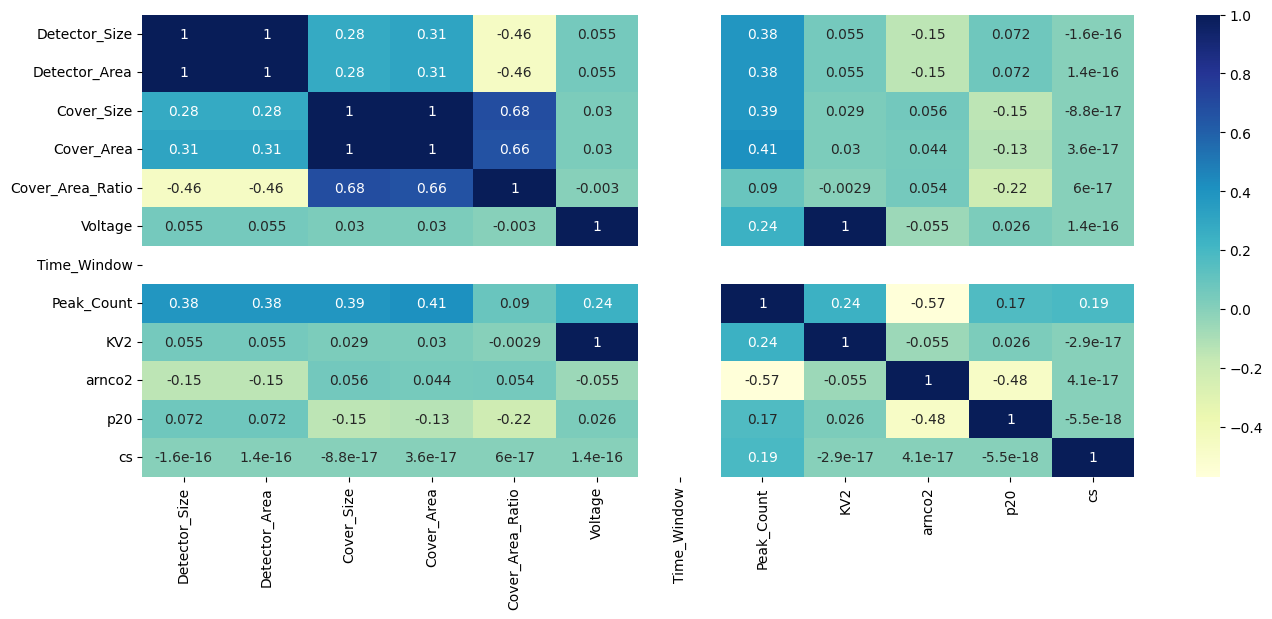

In [19]:
# creation of correlation matrix
corrM = data.corr()
plt.figure(figsize=(16, 6))
dataplot = sns.heatmap(corrM, cmap="YlGnBu", annot=True) 


In [20]:
corr = corrM[abs(corrM['Peak_Count'])>0.1][['Peak_Count']]
list(corr.index)

['Detector_Size',
 'Detector_Area',
 'Cover_Size',
 'Cover_Area',
 'Voltage',
 'Peak_Count',
 'KV2',
 'arnco2',
 'p20',
 'cs']

In [21]:
#data=data[list(corr.index)]
data

,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,Peak_Count,KV2,arnco2,p20,cs
32551,10.00,100.00,4.00,16.00,0.16,4500,15,7,20.25,0.0,1.0,0.0
49310,10.00,100.00,6.00,36.00,0.36,5000,15,0,25.00,1.0,0.0,0.0
49074,10.00,100.00,6.00,36.00,0.36,5500,15,0,30.25,1.0,0.0,1.0
19806,6.78,45.97,6.68,44.62,0.97,5000,15,45,25.00,0.0,0.0,0.0
37271,10.00,100.00,8.00,64.00,0.64,5000,15,208,25.00,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
41759,6.78,45.97,4.78,22.85,0.50,4500,15,3,20.25,0.0,1.0,1.0
48596,10.00,100.00,6.00,36.00,0.36,5000,15,0,25.00,1.0,0.0,1.0
11074,10.00,100.00,4.00,16.00,0.16,5000,15,71,25.00,0.0,0.0,0.0
1642,10.00,100.00,6.00,36.00,0.36,5500,15,155,30.25,0.0,0.0,1.0


In [22]:
from sklearn.model_selection import train_test_split

In [23]:
x=data.drop(['Peak_Count'],axis=1)

x.head()

,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,arnco2,p20,cs
32551,10.00,100.00,4.00,16.00,0.16,4500,15,20.25,0.0,1.0,0.0
49310,10.00,100.00,6.00,36.00,0.36,5000,15,25.00,1.0,0.0,0.0
49074,10.00,100.00,6.00,36.00,0.36,5500,15,30.25,1.0,0.0,1.0
19806,6.78,45.97,6.68,44.62,0.97,5000,15,25.00,0.0,0.0,0.0
37271,10.00,100.00,8.00,64.00,0.64,5000,15,25.00,0.0,1.0,1.0


In [24]:
y=data['Peak_Count']
y

32551      7
49310      0
49074      0
19806     45
37271    208
        ... 
41759      3
48596      0
11074     71
1642     155
11071     73
Name: Peak_Count, Length: 612, dtype: int64

In [25]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [26]:
from sklearn.linear_model import LinearRegression

In [27]:
model=LinearRegression()

In [28]:
model.fit(X_train,y_train)

LinearRegression()

In [29]:
pred=model.predict(X_test)
pred

array([ 72.91909343,  35.5908398 ,  12.8320404 , 104.51009559,
       137.11376123, 137.11376123, -30.34326753, 102.43600472,
        97.56951763, 213.27474837, 103.54939076,  61.15218918,
        78.76614773,  58.6345109 , 198.99016584, 109.96260777,
        61.33478767, 205.74814532,  60.37408283,  35.8757115 ,
       -66.76059597, 213.27474837,  49.87542233,  95.05183935,
        95.67802523, -66.76059597, 213.27474837, 101.80981883,
       101.80981883,  38.24133692, -30.34326753,  86.29275077,
       144.64036428, 109.33642188,  75.6193702 , 205.74814532,
       -66.76059597,  39.20204175,  86.29275077,  -0.54161694,
        60.37408283,  32.26146379, 101.80981883, 162.57283739,
       102.43600472,   6.9849861 ,  12.8320404 , 170.44420292,
       -23.58528805,  32.26146379,  32.26146379,  -0.54161694,
        24.91745922,  86.29275077,  61.15218918, 206.86153137,
        72.00816824, -29.43234234,  61.33478767, 109.96260777,
        17.97688125,  58.6345109 , -66.76059597, -52.47

In [30]:
y_test

25232    127
43407      2
62763      0
56153      2
5418      34
        ... 
5422      25
13673    245
5651      84
9891     109
11310     66
Name: Peak_Count, Length: 123, dtype: int64

In [31]:
X_test

,Detector_Size,Detector_Area,Cover_Size,Cover_Area,Cover_Area_Ratio,Voltage,Time_Window,KV2,arnco2,p20,cs
25232,10.00,100.00,6.00,36.00,0.36,5000,15,25.00,0.0,1.0,0.0
43407,6.78,45.97,4.78,22.85,0.50,4500,15,20.25,0.0,1.0,0.0
62763,6.78,45.97,4.78,22.85,0.50,5500,15,30.25,1.0,0.0,1.0
56153,10.00,100.00,8.00,64.00,0.64,5500,15,30.25,1.0,0.0,1.0
5418,10.00,100.00,6.00,36.00,0.36,5500,15,30.25,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
5422,10.00,100.00,6.00,36.00,0.36,5500,15,30.25,0.0,0.0,0.0
13673,10.00,100.00,8.00,64.00,0.64,5000,15,25.00,0.0,0.0,0.0
5651,10.00,100.00,6.00,36.00,0.36,4500,15,20.25,0.0,0.0,1.0
9891,10.00,100.00,4.00,16.00,0.16,5500,15,30.25,0.0,0.0,1.0


In [32]:
model.score(X_test, y_test)

0.6010069016187948

In [33]:
pred

array([ 72.91909343,  35.5908398 ,  12.8320404 , 104.51009559,
       137.11376123, 137.11376123, -30.34326753, 102.43600472,
        97.56951763, 213.27474837, 103.54939076,  61.15218918,
        78.76614773,  58.6345109 , 198.99016584, 109.96260777,
        61.33478767, 205.74814532,  60.37408283,  35.8757115 ,
       -66.76059597, 213.27474837,  49.87542233,  95.05183935,
        95.67802523, -66.76059597, 213.27474837, 101.80981883,
       101.80981883,  38.24133692, -30.34326753,  86.29275077,
       144.64036428, 109.33642188,  75.6193702 , 205.74814532,
       -66.76059597,  39.20204175,  86.29275077,  -0.54161694,
        60.37408283,  32.26146379, 101.80981883, 162.57283739,
       102.43600472,   6.9849861 ,  12.8320404 , 170.44420292,
       -23.58528805,  32.26146379,  32.26146379,  -0.54161694,
        24.91745922,  86.29275077,  61.15218918, 206.86153137,
        72.00816824, -29.43234234,  61.33478767, 109.96260777,
        17.97688125,  58.6345109 , -66.76059597, -52.47

In [34]:
y_test

25232    127
43407      2
62763      0
56153      2
5418      34
        ... 
5422      25
13673    245
5651      84
9891     109
11310     66
Name: Peak_Count, Length: 123, dtype: int64

In [35]:
indexes = X_test.index.values
#index=indexes[98]

In [36]:
#X_test.loc[index]

In [37]:
#y_test[index],pred[98]
pred[pred<=0] = 0

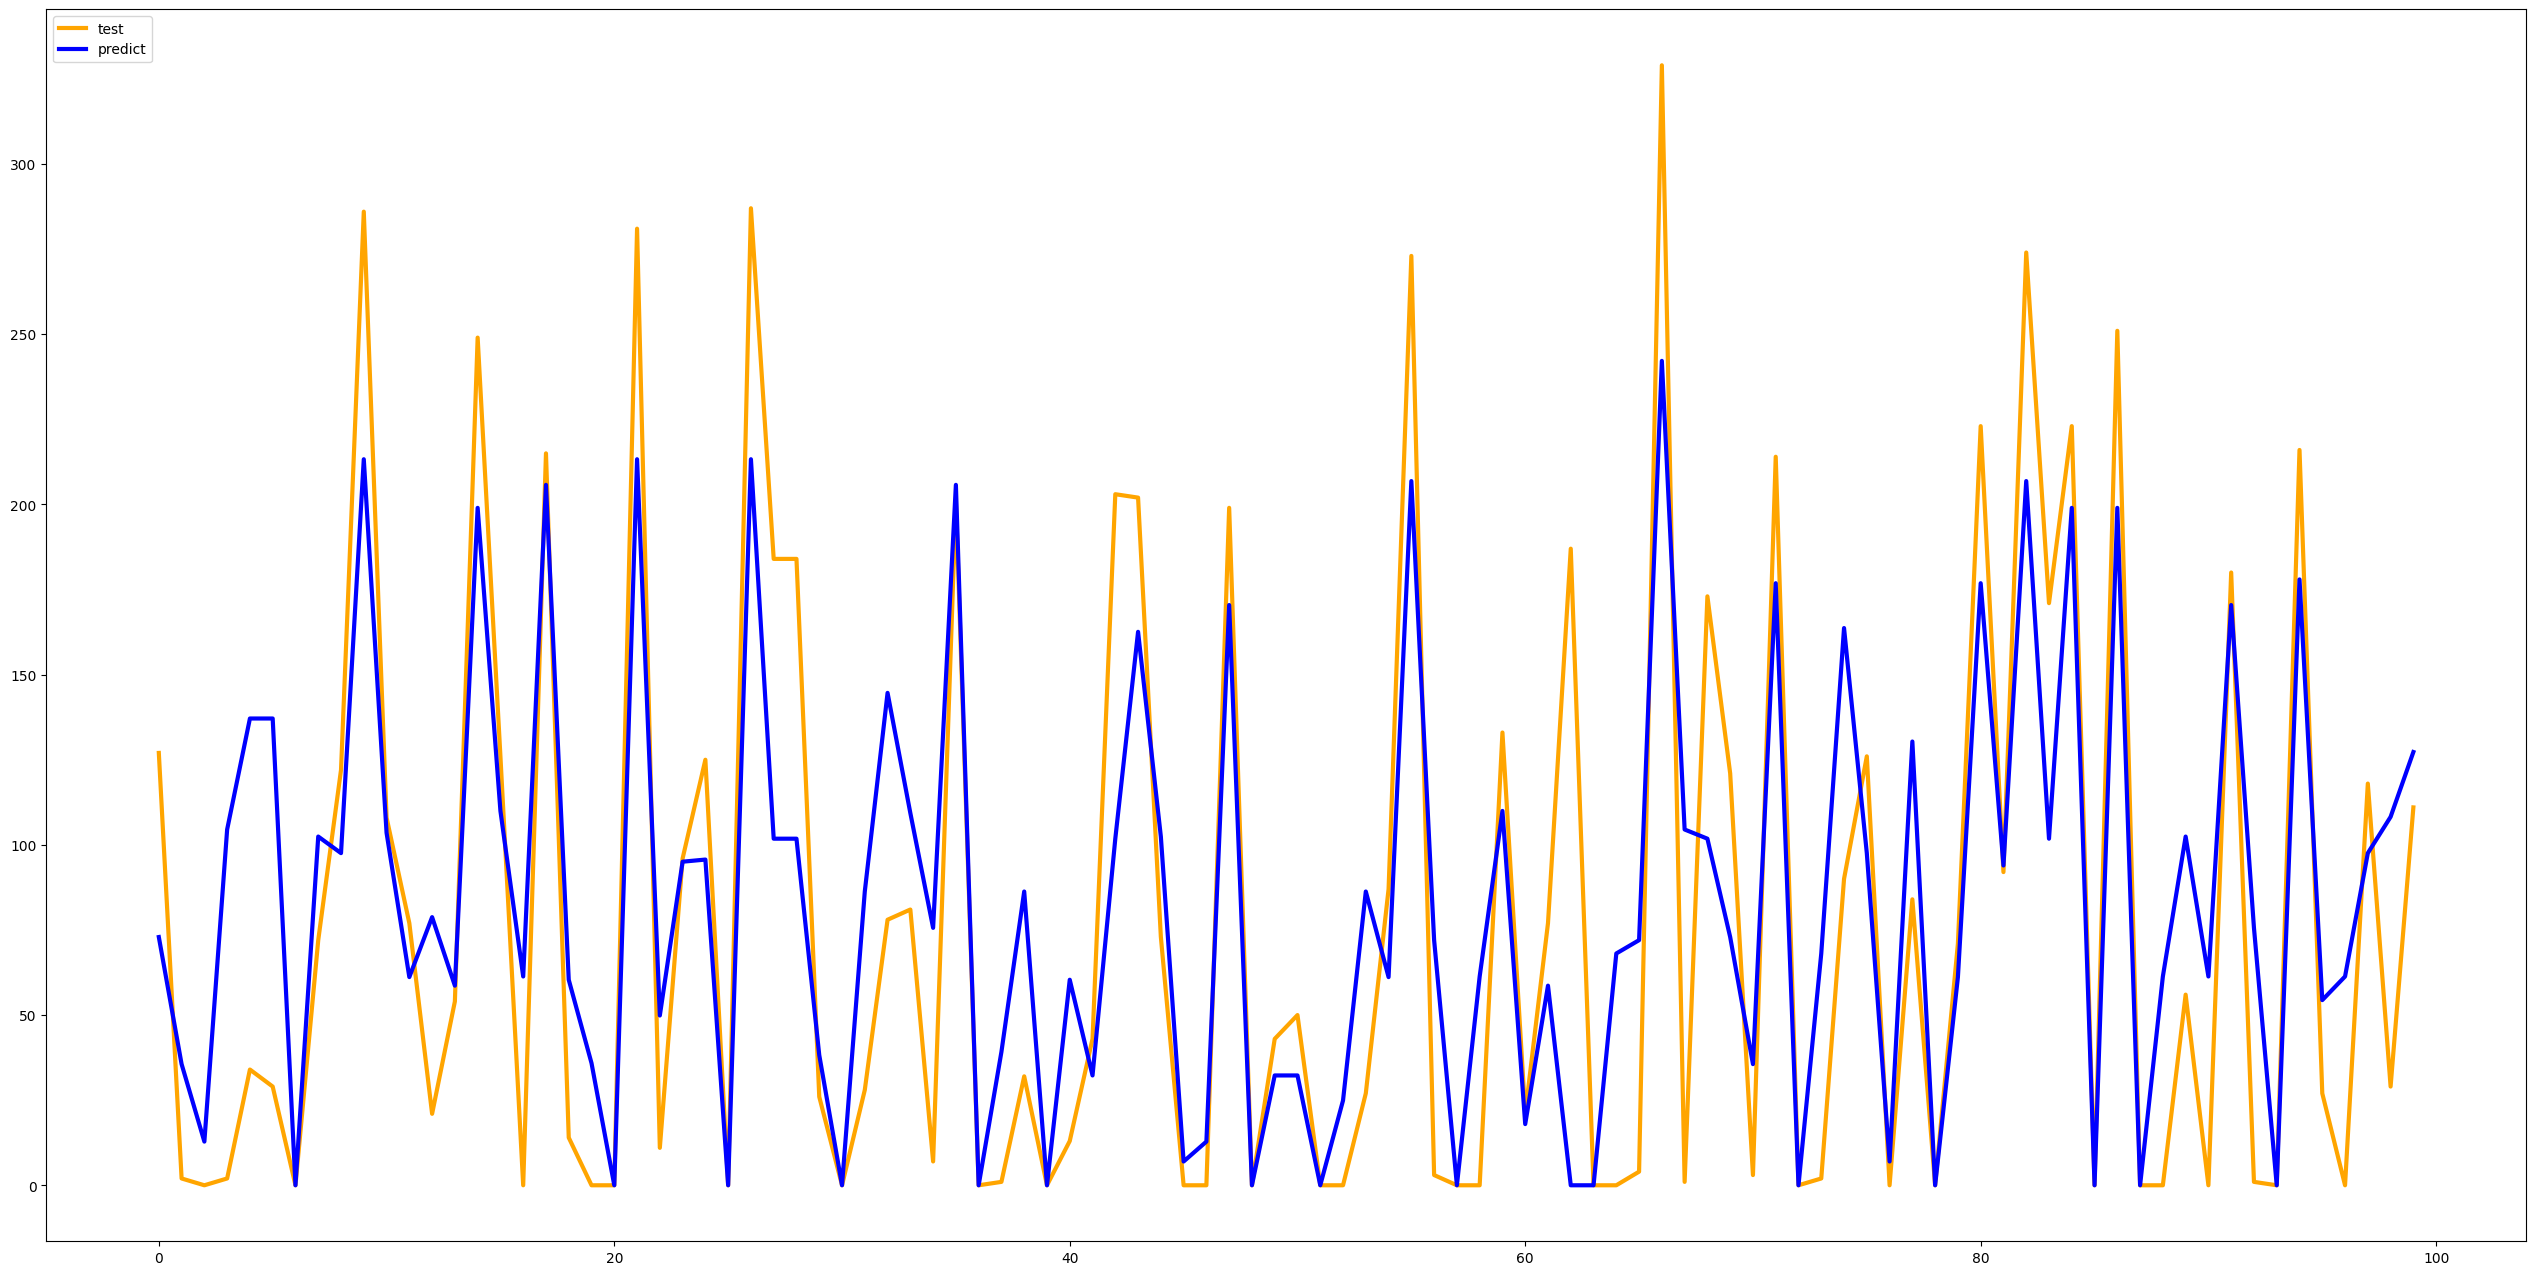

In [38]:
plt.figure(figsize=(32, 16))
plt.plot(range(0,len(indexes))[:100],y_test[:100], color="orange", linewidth=3 ,label = 'test')
plt.plot(range(0,len(indexes))[:100],pred[:100], color="blue", linewidth=3,label = 'predict')
plt.legend(loc="upper left")
plt.show()

In [39]:
indexes = X_test.index.values
#index=indexes[98]

In [40]:
#X_test.loc[index]

In [41]:
#y_test[index],pred[98]

In [42]:
#metrics.mean_absolute_error(y_true, y_pred, *) -> Mean absolute error regression loss.
metrics.mean_absolute_error(y_test, pred)

38.70796999551384

In [43]:
#metrics.mean_squared_error(y_true, y_pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)

2602.6934630065434

In [44]:
#metrics.mean_squared_error(y_true, pred, *) -> Mean squared error regression loss.
metrics.mean_squared_error(y_test, pred)**0.5

51.01659987696694

In [45]:
#metrics.mean_absolute_percentage_error(...) -> Mean absolute percentage error (MAPE) regression loss.

In [46]:
metrics.mean_absolute_percentage_error(y_test, pred)

1.9892241977869868e+16

In [47]:
#metrics.r2_score(y_true, y_pred, *[, ...]) -> (coefficient of determination) regression score function.
metrics.r2_score(y_test, pred)

0.6663655296959564

In [48]:
metrics.explained_variance_score(y_test, pred)

0.6738697059315504